---

# Part 1 · What is an AI assistant?

## 1.1 Learning outcomes

After this part you will be able to:

- Say what an AI assistant is and give everyday examples.
- Distinguish a traditional chatbot from an AI (LLM-based) assistant.
- Explain, in simple words, what a **large language model (LLM)** is.
- Understand the ideas of **tokens**, **context** and **generation**.
- Run your first tiny "assistant" written in Python.

## 1.2 What is an AI assistant?

An **AI assistant** is a computer program that understands natural language
(text you type or speak) and replies in a way that helps you complete a task.
You already use them:

- **Virtual helpers** on phones (answering questions, setting alarms).
- **Customer-support chatbots** on websites.
- **Writing/coding assistants** that finish a sentence or fix a bug.
- **Voice assistants at home** that play music or turn off the lights.

### Assistant vs. traditional chatbot

A *traditional* chatbot follows a fixed set of rules. If you ask a question it
was not programmed for, it replies with a canned message such as "Sorry, I did
not understand." It cannot create new answers.

An *AI* assistant is different: it **generates** a reply on the fly, based on a
huge amount of text it has "read" during training. It can explain, translate,
summarize, and even hold a conversation about things it never saw verbatim.

# Introduction to AI Assistants

## Course overview

| Part | Topic |
|------|-------|
| **Part 1** | What is an AI assistant? Core concepts: LLMs, tokens, context. |
| **Part 2** | Prompt engineering fundamentals: roles, temperature, few-shot, persona, chain-of-thought, iteration. |
| **Part 3** | Building an assistant interface: conversation and memory. |
| **Part 4** | Advanced capabilities (tools, RAG, agents), using AI for academic sources, limits and ethics. |

## How to use this notebook

- Run the cells **in order** with `Shift + Enter`.
- **Markdown cells** (like this one) contain the theory - please read them.
- **Code cells** contain small examples. Run them and observe the output.
- The notebook works **out of the box**: no internet and no API key are needed.
  A built-in "teaching assistant" simulates a language model so you can learn
  basic ideas for free. In **Part 3** you will see how to connect a real model
  with an API key.

**Tip:** This is not a programming course. If you see code you do not fully
understand, that is okay - the explanations next to it matter more. All code
is kept short and commented.

## 1.3 Core idea: the large language model (LLM)

Think of an LLM as a person who has read **almost all books and websites in many
languages** and learned how words are usually combined. It does not "know"
facts the way a database does; instead it has learned **patterns** of language.

The assistant's job is simple on paper:

1. You provide some text (your **prompt** / question).
2. The model looks at the text it has so far.
3. It **predicts** the most likely next word.
4. It repeats step 3 again and again until it produces a full reply.

Because step 3 involves *probability* and *randomness*, the same question asked
twice may give two different - but both valid - answers. We will explore this
in Part 2 (parameter called **temperature**).

<div style="background:#eef7ee;border-left:4px solid #2e7d32;padding:8px 12px;">
<strong>Analogy.</strong> Imagine writing a text with a friend who fills in the
next word: you write <em>"The sky is"</em>, and the friend suggests
<em>"blue"</em>. Now you have <em>"The sky is blue"</em> and the friend suggests
the next word after that. An LLM works this way, but it has "read" billions of
documents, so its suggestions are usually very good.
</div>

What we called the **prompt** is everything you send in - the question, extra
context, and instructions. We will design prompts carefully in Part 2.

## 1.4 Tokens: the "words" the model reads

A model does not read letters directly. It reads **tokens** - small pieces of
text. Often a token is a word (or a word piece). Spaces count too.

Rough rule used in this course: **1 token ≈ 4 characters** of English text.

Examples of token boundaries (approximately, for illustration):

- `assistant` → tokens: `assi` + `stant` (2 tokens)
- `Hello! How are you?` → roughly 5 tokens

Why does this matter? Because the model's memory - the **context window** - is
measured in tokens, not words, and you are often billed by the number of tokens.
We will see the context window again in Parts 3 and 4.

Let's write a tiny function that estimates tokens so we get a feel for it.

In [1]:
import math

# A rough estimate: real models count tokens with a special "tokenizer",
# but this formula gives us an intuitive feel. 1 token ~ 4 characters.
def estimate_tokens(text: str) -> int:
    """Return a rough estimate of how many tokens a text contains."""
    return max(1, math.ceil(len(text) / 4))


# Let's try a few examples.
examples = [
    "Hello!",
    "The sky is blue.",
    "assistant" * 10,            # a long word repeated -> many tokens
    "How do AI assistants work?" * 100,  # a long sentence-repeated text
]
for text in examples:
    print(f"characters: {len(text):6}  ≈ tokens: {estimate_tokens(text):6}  |  {text[:30]}...")

characters:      6  ≈ tokens:      2  |  Hello!...
characters:     16  ≈ tokens:      4  |  The sky is blue....
characters:     90  ≈ tokens:     23  |  assistantassistantassistantass...
characters:   2600  ≈ tokens:    650  |  How do AI assistants work?How ...


## 1.5 Why counting tokens matters

Counting tokens is not just an exercise - it drives three practical things in
every real assistant:

- **Cost.** Most providers charge by the token (input + output). Fewer tokens = cheaper.
- **Speed.** The model must process every token in each request, so longer
  prompts respond more slowly.
- **Context.** The model's short-term "memory" is measured in tokens (the
  context window). The larger the prompt, the less room remains for the answer.

Below we first try a rough **cost estimate** (illustrative prices only - actual
pricing varies by provider), then we draw a picture of how character count maps
to tokens.

In [2]:
# An illustrative cost example. Prices vary by provider - the numbers below are
# made up only to show the idea. We reuse estimate_tokens() defined earlier.
price_per_1k = 0.005   # example: $0.005 per 1000 tokens (illustrative)

def cost_dollars(text: str) -> float:
    """Return a rough cost in dollars for a piece of text (illustrative)."""
    return estimate_tokens(text) / 1000 * price_per_1k

prompt = "Why do AI assistants sometimes make mistakes? Please explain in two sentences."
tokens = estimate_tokens(prompt)
print(f"prompt length: {len(prompt):3d} chars  ≈  {tokens} tokens")
print(f"approx. input cost: ${cost_dollars(prompt):.6f} (illustrative)")
print(f"a 20-turn chat ≈ ${cost_dollars(prompt) * 20 * 2:.4f} (illustrative)")

prompt length:  78 chars  ≈  20 tokens
approx. input cost: $0.000100 (illustrative)
a 20-turn chat ≈ $0.0040 (illustrative)


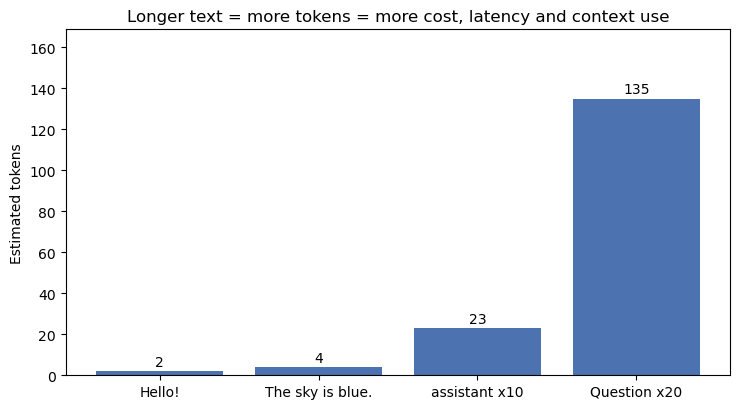

In [3]:
import matplotlib.pyplot as plt

# The same samples shown in the token demo, plus their token estimates.
samples = ["Hello!", "The sky is blue.", "assistant" * 10,
           "How do AI assistants work? " * 20]
labels  = ["Hello!", "The sky is blue.", "assistant x10", "Question x20"]
counts  = [estimate_tokens(s) for s in samples]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(range(len(counts)), counts, color="#4c72b0")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(labels)
ax.set_ylabel("Estimated tokens")
ax.set_title("Longer text = more tokens = more cost, latency and context use")
for i, v in enumerate(counts):
    ax.text(i, v + max(counts) * 0.02, str(v), ha="center")
ax.set_ylim(0, max(counts) * 1.25)
plt.tight_layout()
plt.show()

## 1.6 Our first "assistant": a scripted one

Before we talk to a real language model, we will build a tiny **scripted
assistant** in Python. It has no AI at all - it just follows rules (like a
traditional chatbot). Building it teaches us two things:

1. The structure of a program that "talks" to a user (a **conversation loop**).
2. The difference between **rule-based** behavior (this example) and **model-based**
   generation (what you will trade it for later).

The code below introduces two important ideas you will reuse everywhere:

- A **class** is a blueprint for an object. Our assistant is an object that can
  hold its own memory (history) and respond to messages.
- A **method** is a function attached to an object, here `chat()`.

In [2]:
class ScriptedAssistant:
    """A tiny rule-based assistant. No AI, but useful for learning.

    It keeps a short memory (self.history) of what was said, just like a real
    assistant keeps the conversation. Look for the regular rules inside the
    method `_rule_response` below.
    """

    def __init__(self, name: str = "Buddy") -> None:
        self.name = name
        self.history: list[tuple[str, str]] = []  # (role, text) pairs

    def _rule_response(self, user_text: str) -> str:
        """Return a fixed answer based on what the user typed."""
        t = user_text.lower()
        if "hello" in t or "hi" in t:
            return f"Hello! I am {self.name}, your teaching assistant. Ask me something!"
        if "name" in t:
            return f"My name is {self.name}."
        if "weather" in t:
            return "I am only a scripted assistant, I cannot check the weather. A real model could use a tool for that (Part 4)."
        if "advantage" in t or "benefit" in t:
            return "AI assistants save time, answer instantly, and explain hard ideas simply."
        return "I did not understand. Try asking about: hello, your name, weather, or benefits."

    def chat(self, user_text: str) -> str:
        """Add the user message, reply, remember the whole conversation."""
        self.history.append(("user", user_text))
        reply = self._rule_response(user_text)
        self.history.append(("assistant", reply))
        return reply

In [5]:
# Let's create our assistant and talk to it.
buddy = ScriptedAssistant(name="Bud")

# A short conversation. Notice: every result depends only on keywords.
print(buddy.chat("Hello!"))
print(buddy.chat("What is your name?"))
print(buddy.chat("What are the benefits of AI assistants?"))
print(buddy.chat("Tell me about philosophy of ancient Greece"))  # not in the rules
print(buddy.chat("Tell me about advantage of ancient Greece"))  # not in the rules

print("\n--- Conversation history (what the assistant remembers) ---")
for role, text in buddy.history:
    print(f"{role:>9}: {text}")

Hello! I am Bud, your teaching assistant. Ask me something!
My name is Bud.
AI assistants save time, answer instantly, and explain hard ideas simply.
Hello! I am Bud, your teaching assistant. Ask me something!
AI assistants save time, answer instantly, and explain hard ideas simply.

--- Conversation history (what the assistant remembers) ---
     user: Hello!
assistant: Hello! I am Bud, your teaching assistant. Ask me something!
     user: What is your name?
assistant: My name is Bud.
     user: What are the benefits of AI assistants?
assistant: AI assistants save time, answer instantly, and explain hard ideas simply.
     user: Tell me about philosophy of ancient Greece
assistant: Hello! I am Bud, your teaching assistant. Ask me something!
     user: Tell me about advantage of ancient Greece
assistant: AI assistants save time, answer instantly, and explain hard ideas simply.


Notice what happened: our scripted assistant **cannot answer** a question about
ancient Greece because no rule covers it. A real AI assistant would produce a
reasonable answer, because a language model generates a reply instead of
matching a rule. This is the single biggest idea of the whole course:
**rules vs. generation**.

## 1.7 What makes the AI assistant better: a quick preview

Take the exact same conversation and imagine the assistant is a language model.
The model would:

1. Turn all the text (history + new message) into tokens.
2. Predict the next word, then the next, and so on, to form an answer.
3. But tokens are limited - the **context window** - which is why real
   assistants must sometimes "forget" old parts (Part 3).

We now have the vocabulary to discuss all of this precisely. Let's summarize
Part 1 before moving on.

## 1.8 Part 1 - key takeaways

- An **AI assistant** understands and generates natural language.
- Traditional chatbots use **rules**; AI assistants use a **language model** that *generates* replies.
- An **LLM** predicts the next word and continues until the answer is complete.
- Text is handled as **tokens**; roughly **1 token ≈ 4 characters**.
- Tokens drive real-world **cost, speed and context** usage.
- The **context window** = the model's short-term memory, measured in tokens.
- We built our first scripted assistant and saw why rules are limiting.

**Self-check (think, then continue):**
1. A classmate asks "Is a phone's FAQ bot an AI assistant?" - how would you answer?
2. Why can the same AI question give two different answers?
3. If a model's context window is 8000 tokens, about how many characters is that?
4. Why should a company care about reducing the number of tokens its assistant sends?

---
In **Part 2** we will learn how to "talk" to an AI model properly: the anatomy
of a prompt, system vs. user messages, and the temperature parameter.

---

# Part 2 · Prompt engineering fundamentals

*How we "talk" to an assistant.*

## 2.1 Learning outcomes

After this part you will be able to:

- Explain the anatomy of a **prompt**.
- Distinguish **system**, **user** and **assistant** message roles.
- Explain what **temperature** controls and choose a sensible value.
- Use the core prompt engineering techniques: **few-shot**, **persona**,
  **chain-of-thought**, **output control**, and **iterating** on a prompt.
- Understand why good instructions give good results - "garbage in, garbage out".

## 2.2 The anatomy of a prompt

A prompt is simply **the text you send to the model**. A good prompt often has
three ingredients:

1. **Instructions** - what you want the model to do ("Summarize this in two sentences.").
2. **Context** - the background information the model needs ("This is a review of a restaurant.").
3. **Examples** - a few input-output pairs showing the expected style (few-shot).

Real systems wrap the prompt into **messages with roles**. There are three roles:

| Role | Meaning | Analogy |
|------|---------|---------|
| `system` | How the assistant should behave (personality + rules) | The employee handbook |
| `user` | What a person typed | What the customer says |
| `assistant` | What the model replied | What the employee answers |

The **system message** is set once at the start. It says things like
"You are a patient teacher. Answer in simple English." Then the user and
assistant take turns.

## 2.3 A teaching model (with real generation)

We now replace the rule-based assistant with a small **model-like** assistant.
It is not a real LLM (that needs an API), but it *behaves* like one: it accepts
a prompt, applies a system message, and returns an answer that depends on both.
This lets us practice before connecting to a real model in Part 3.

In [6]:
import random
import textwrap


class TeachingModel:
    """A small mock of a language model, used for offline teaching.

    It is NOT a real LLM. It demonstrates the *interface* between your program
    and a language model: you send a list of messages with roles; it returns a
    generated reply. Later (Part 3) we will point the same code at a real API.
    """

    system_prompt = "You are a helpful teacher of AI assistants. Answer briefly and clearly."

    # A tiny set of "learned" responses keyed by topic, just to make examples lively.
    _knowledge = {
        "sql": "SQL is a language for talking to databases (SELECT, INSERT, ...)",
        "python": "Python is a popular, easy-to-read programming language",
        "assistant": "an AI assistant is a program that understands and generates natural language",
    }

    def __init__(self, temperature: float = 0.7) -> None:
        self.temperature = temperature

    def chat(self, messages: list[dict], temperature: float | None = None) -> str:
        """Send a conversation (list of {role, content}) and get a reply."""
        temp = float(self.temperature if temperature is None else temperature)

        # 1. Collect the most important user question in a lowercase form.
        user_texts = [m["content"] for m in messages if m["role"] == "user"]
        last_user = user_texts[-1] if user_texts else ""
        low = last_user.lower()

        # 2. Look for a known topic anywhere in the question (simulates "understanding").
        known = next((v for k, v in self._knowledge.items() if k in low), None)
        if known is not None:
            base = known
        elif "summar" in low:
            base = "A summary should keep only the key points and a short title"
        else:
            # 3. Otherwise, build a short generic answer and mention the question.
            base = "I am paying attention to your question about '{0}'".format(last_user[:40].strip())

        # 4. React to style cues found in the system message OR the user message.
        #    This imitates how a real model follows persona and format instructions.
        system = next((m["content"] for m in messages if m["role"] == "system"), "")
        check = system + " " + last_user
        if "rhyme" in system:
            closing = " Let me answer in a gentle rhyme."
        elif "brief" in check or "short" in check or "one sentence" in check:
            closing = " Keep it short for you."
        else:
            closing = " Here is a clear explanation for you."

        # 5. Simulate randomness controlled by temperature.
        proposal = base + closing
        if temp <= 0.1:
            return proposal  # near-zero temperature -> always the same answer

        # Higher temperature -> the model may pick a different (but valid) wording.
        variants = [
            proposal,
            "Actually, there is another good way to put it: " + base + ".",
            base + " Does this make sense so far?",
        ]
        return random.choice(variants)


# A tiny helper that every example in this part uses. It mimics the "API call":
# a fixed system message, one user message, and one answer comes back.
def ask(model: TeachingModel, user_text: str, system_prompt: str,
        temperature: float | None = None) -> str:
    """Wrap a single question into proper messages and ask the model."""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_text},
    ]
    return model.chat(messages, temperature=temperature)

### Example 1: The system message shapes the whole answer

The same question, but with two different **system messages**, produces two
different replies. This is why the system prompt is so powerful: it is the
"instructions manual" that shapes every answer.

In [7]:
model = TeachingModel(temperature=0.0)  # low temperature -> stable answers

systems = {
    "teacher": "You are a friendly university teacher. Answer briefly and clearly.",
    "poet":    "You are a poet who always answers in rhyme.",
}

for label, system_prompt in systems.items():
    reply = ask(model, "What is SQL?", system_prompt=system_prompt, temperature=0.0)
    print(f"[{label} system prompt]")
    print(reply)
    print("-" * 50)

[teacher system prompt]
SQL is a language for talking to databases (SELECT, INSERT, ...) Keep it short for you.
--------------------------------------------------
[poet system prompt]
SQL is a language for talking to databases (SELECT, INSERT, ...) Let me answer in a gentle rhyme.
--------------------------------------------------


What we learn here: **instructions matter**. Change the system prompt and the
assistant's whole personality and style change with it. Real assistants do the
same - companies tune system prompts to make assistants safe, helpful and on-brand.

## 2.4 Temperature: controlling creativity

Remember that a language model *predicts the next word*. When ranked, there is
usually a most-likely word, but also other good options. **Temperature** controls
how strictly we pick the top option:

- **Low (0 to 0.3)** → the model almost always picks the most likely word.
  Result: predictable, factual, repeatable. Good for facts, code, summaries.
- **Medium (0.5 to 0.8)** → a good mix. Good for explanations and conversation.
- **High (0.8 to 1.5+)** → the model explores less likely words.
  Result: creative, varied. Good for brainstorming and stories.

Let's demonstrate with our model: same question, many times, at different
temperatures.

In [8]:
import random

random.seed(42)          # fix the random stream so results are comparable
model = TeachingModel()

print("=== Same question, temperature = 0.0 (deterministic) ===")
for _ in range(5):
    print(">", ask(model, "What is Python?", system_prompt=model.system_prompt,
                   temperature=0.0))

print("\n=== Same question, temperature = 1.5 (more variety) ===")
for _ in range(5):
    print(">", ask(model, "What is Python?", system_prompt=model.system_prompt,
                   temperature=1.5))
random.seed()  # reset so later examples are not affected

=== Same question, temperature = 0.0 (deterministic) ===
> Python is a popular, easy-to-read programming language Keep it short for you.
> Python is a popular, easy-to-read programming language Keep it short for you.
> Python is a popular, easy-to-read programming language Keep it short for you.
> Python is a popular, easy-to-read programming language Keep it short for you.
> Python is a popular, easy-to-read programming language Keep it short for you.

=== Same question, temperature = 1.5 (more variety) ===
> Python is a popular, easy-to-read programming language Does this make sense so far?
> Python is a popular, easy-to-read programming language Keep it short for you.
> Python is a popular, easy-to-read programming language Keep it short for you.
> Python is a popular, easy-to-read programming language Does this make sense so far?
> Actually, there is another good way to put it: Python is a popular, easy-to-read programming language.


At temperature `0.0` the answer is **the same every time**; at higher
temperature the wording changes. Real models behave in a similar, though richer,
way. Practical rule: *use low temperature when you want facts, high temperature
when you want ideas.*

## 2.5 Few-shot prompting: teaching by example

Sometimes we want the assistant to answer in a very specific style or format
(JSON, a table, a tone). The easiest way is to **show it examples inside the
prompt**. Giving the model some `user -> assistant` pairs before the real
question is called **few-shot prompting**.

### Without examples (zero-shot)

We just ask. The model decides the format itself.

## Why does temperature work? A look at sampling

A model does not simply "pick the best" word. For each next word it computes a
score for every candidate in its vocabulary, then turns those scores into
probabilities (the technical name for this step is **softmax**). **Temperature**
is the knob that shapes those probabilities:

- **Low temperature** makes the most-likely word *dominate*: the distribution
  becomes sharp, so answers are focused and repeatable.
- **High temperature** *flattens* the distribution, so less-likely words get a
  real chance, and answers become varied and creative.

The chart below shows the same fictional "next-word probabilities" at three
temperatures. Watch how the tallest bar grows at low temperature and gets
smaller at high temperature.

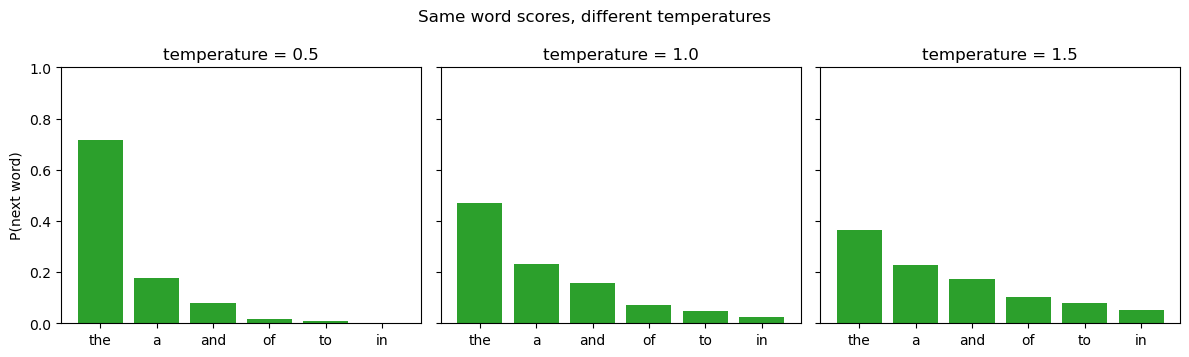

Key idea: low temperature lets one word dominate; high temperature gives
the others a chance - that is why answers become more varied.


In [9]:
import numpy as np

# Softmax turns "scores" into probabilities. It is the only math we need here.
def softmax(x):
    """Convert raw scores into probabilities that sum to 1."""
    ex = np.exp(x - np.max(x))
    return ex / ex.sum()

words  = ["the", "a", "and", "of", "to", "in"]
logits = np.array([2.3, 1.6, 1.2, 0.4, 0.0, -0.6])  # the model's scores

fig, axs = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, T in zip(axs, [0.5, 1.0, 1.5]):
    p = softmax(logits / T)          # temperature scales the scores
    ax.bar(range(len(words)), p, color="#2ca02c")
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words)
    ax.set_title(f"temperature = {T}")
    ax.set_ylim(0, 1)
axs[0].set_ylabel("P(next word)")
fig.suptitle("Same word scores, different temperatures", fontsize=12)
plt.tight_layout()
plt.show()

print("Key idea: low temperature lets one word dominate; high temperature gives")
print("the others a chance - that is why answers become more varied.")

In [10]:
# Zero-shot: no examples given.
model = TeachingModel(temperature=0.0)
reply = ask(
    model,
    "Summarize this text: 'The meeting starts at 9. We will discuss the budget and then the new project.'",
    system_prompt="You are a helpful assistant.",
    temperature=0.0,
)
print("Zero-shot reply:")
print(reply)

Zero-shot reply:
A summary should keep only the key points and a short title Here is a clear explanation for you.


### With few-shot examples

Now we give the model two clean examples of the *exact format* we want. The
model learns "when you see a summary request, reply with a `Title:` line and a
`Key points:` list" - even though our mock can only imitate this partially,
the idea is the key thing to understand.

In [11]:
# Few-shot: two worked examples define the required format.
few_shot_messages = [
    {"role": "system", "content": "You are a precise summarizer."},
    {"role": "user", "content": "Summarize: 'We will start the workshop with a short talk.'"},
    {"role": "assistant", "content": "Title: Workshop start\nKey points:\n- short opening talk\n- participants meet"},
    {"role": "user", "content": "Summarize: 'Lunch is at noon; the lab opens after lunch.'"},
    {"role": "assistant", "content": "Title: Lunch and lab\nKey points:\n- lunch at noon\n- lab opens after lunch"},
    # --- And now the real question, following the same pattern: ---
    {"role": "user", "content": "Summarize: 'The meeting starts at 9; we discuss budget, then the project.'"},
]

model = TeachingModel(temperature=0.0)
print("Few-shot reply:")
print(model.chat(few_shot_messages))

Few-shot reply:
A summary should keep only the key points and a short title Here is a clear explanation for you.


With a real model, few-shot prompting reliably produces the format you showed.
This is called **in-context learning**: the model learns from examples inside the
prompt, without retraining. It is one of the most useful prompting techniques.

> **Important:** the more unusual the format you want, the more examples you need
> (and the more tokens your prompt uses up).

In the next cells we expand our toolkit of **prompt engineering fundamentals**:
persona prompting, chain-of-thought, output control, and iterating on prompts.
Then we summarize what we have learned.

## 2.6 More prompt engineering fundamentals

Each technique is a small, reusable trick. We already know a big one
(few-shot). Here are four more that every student can use every day:

1. **Persona prompting.** Tell the assistant *who it is* in the system message.
   "You are a patient tutor for beginners." The persona sets the tone, the
   vocabulary and the level of detail. This is how we get one source explained
   "for a child" and "for a professor" from the same model.

2. **Chain-of-thought (CoT).** Ask the model to *reason step by step* before
   giving the final answer ("Show your steps"). It improves results on math,
   logic and analysis tasks, and makes the reasoning visible so we can spot mistakes.

3. **Output control.** Specify the format exactly: "answer in one sentence",
   "as a list of 3 bullet points", "in JSON", "max 100 words". You met this idea
   with few-shot above, and we will use a JSON output this way in Part 4. Being
   precise about format removes ambiguity.

4. **Iteration.** Prompting is rarely one-shot. First answer, then **improve**:
   add missing context, narrow the format, correct a misunderstanding. Good
   prompts are often written in 2-3 quick rounds.

A compact recipe that binds all of this together is our **CATA** method:

- **C**ontext - explain the situation to the model.
- **A**ction - state exactly what you want it to do.
- **T**one / format - say how to respond (briefly, as list, JSON, in rhyme...).
- **A**nticipate - tell it how to handle edge cases ("if unknown, say: I don't know").

The next cells show these techniques in action. Remember: our `TeachingModel`
only *imitates* a real model, so watch the **prompt structure** more than the
exact wording of the replies.

In [12]:
model = TeachingModel(temperature=0.0)  # stable answers for this demo

# 1) PERSONA prompting: we set who the assistant should be via the system prompt.
persona_child = "You are a friendly tutor for a 10-year-old. Use a simple analogy and everyday words."
persona_peer  = "You are a senior engineer explaining to a colleague. Be precise and answer briefly."

for label, persona in [("to a 10-year-old", persona_child), ("to a colleague", persona_peer)]:
    print(f"[persona: explain tokens {label}]")
    print("SYSTEM:", persona)
    print("ASST  :", ask(model, "What is a token in AI?", persona, temperature=0.0))
    print()

# 2) CHAIN-OF-THOUGHT: ask for explicit, visible steps.
cot_prompt = (
    "Solve step by step and show each step.\n"
    "Problem: a library has 7 shelves, and each shelf holds 9 books.\n"
    "How many books fit in total?"
)
print("Chain-of-thought prompt:\n" + cot_prompt + "\n")
# A real model would reason like this (shown here to illustrate the technique):
print("A real model's step-by-step reply would look like:")
print("  Step 1: there are 7 shelves.")
print("  Step 2: each shelf holds 9 books.")
print("  Step 3: 7 x 9 = 63, so 63 books fit in total.")

[persona: explain tokens to a 10-year-old]
SYSTEM: You are a friendly tutor for a 10-year-old. Use a simple analogy and everyday words.
ASST  : I am paying attention to your question about 'What is a token in AI?' Here is a clear explanation for you.

[persona: explain tokens to a colleague]
SYSTEM: You are a senior engineer explaining to a colleague. Be precise and answer briefly.
ASST  : I am paying attention to your question about 'What is a token in AI?' Keep it short for you.

Chain-of-thought prompt:
Solve step by step and show each step.
Problem: a library has 7 shelves, and each shelf holds 9 books.
How many books fit in total?

A real model's step-by-step reply would look like:
  Step 1: there are 7 shelves.
  Step 2: each shelf holds 9 books.
  Step 3: 7 x 9 = 63, so 63 books fit in total.


In [13]:
# 3) OUTPUT CONTROL + 4) ITERATION: compare a weak prompt with an improved one.
# To keep the demo fair, the system message stays the same; only the user prompt changes.
neutral_system = "You are a helpful assistant."

weak = "Explain the context window."

strong = (
    "Explain the context window briefly, in one sentence, and give one everyday "
    "analogy. If you are unsure, say: I don't know."
)

print("WEAK prompt  :", weak)
print("STRONG prompt:", strong, "\n")
print("Reply to weak prompt  :", ask(model, weak, neutral_system, temperature=0.0))
print("Reply to strong prompt:", ask(model, strong, neutral_system, temperature=0.0))

# The point of iteration: the "strong" prompt adds explicit format constraints
# (brief, one sentence, analogy) and an instruction for the edge case. Even our
# tiny mock responds more tightly to it (notice "Keep it short"). A real model
# would also follow the requested structure.

WEAK prompt  : Explain the context window.
STRONG prompt: Explain the context window briefly, in one sentence, and give one everyday analogy. If you are unsure, say: I don't know. 

Reply to weak prompt  : I am paying attention to your question about 'Explain the context window.' Here is a clear explanation for you.
Reply to strong prompt: I am paying attention to your question about 'Explain the context window briefly, in o' Keep it short for you.


## 2.7 Part 2 - key takeaways (prompt engineering fundamentals)

- A prompt contains **instructions, context** and, optionally, **examples**.
- Messages have **roles**: `system` (instructions), `user`, `assistant`.
- **Temperature** ≈ creativity/determinism. Low for facts, high for ideas.
- **Few-shot** teaches format via examples; **persona** sets voice and level;
  **chain-of-thought** improves reasoning; **output control** fixes the format.
- **Iterate**: improve your prompt after seeing the first answer (CATA is a good starting recipe).
- Good instructions → good answers (garbage in, garbage out).

**Self-check (think, then continue):**
1. Why does the same question produce different answers at high temperature?
2. When would you set temperature to 0.1? To 1.5?
3. You need professional-looking table output for your report: which technique or combination helps?
4. Write one prompt (in your own words) that uses persona + output control to ask about a topic you study.

---
In **Part 3** we will see what happens when the conversation has many turns:
how assistants **remember**, and why the context window forces us to manage memory.

---

# Part 3 · Conversation and memory

## 3.1 Learning outcomes

After this part you will be able to:

- Explain why a language model itself has **no memory** between requests.
- Manage a conversation as a growing **message list** (the only "memory").
- Describe the **context window** limit and two strategies to handle it
  (truncation and summarization).
- Understand at a high level how a program **connects to a real model** through an API.
- Explain why we usually do **not** hardcode credentials into notebooks.

## 3.2 The big secret: the model is "stateless"

Here is the most important misconception to fix. When you send a question to a
language model, the model **does not remember** anything you said before. Every
time you message it, it sees only the text you send in that request.

So how does a chat assistant seem to remember the conversation?

Because the *program around the model* keeps the **full message list** and sends
**all of it** with every new request. That message list *is* the memory.

```
Your program keeps the list:            On every new question, the program
                                        sends the WHOLE list to the model API
  [system]     You are ...              ---------------------------
  [user]       Hello!                         |
  [assistant]  Hi!                            v
  [user]       My name is Anna ---------> [whole message list]
                                                      |
                                                        v
                                                  model API
                                          (the model answers only the
                                           latest user message)
```

Each round, the whole `[system] + previous turns + new user message` is sent.
That is why longer conversations "cost more" (more tokens) and, when the list
grows beyond the **context window**, the program must shorten or remove old parts.

## 3.3 The context window and how to manage it

The **context window** is the maximum number of tokens a model can look at in
one request (like short-term memory). Modern models vary a lot here: older ones
handled a few thousand tokens, many current ones handle tens of thousands, and
the largest can exceed a hundred thousand - but even huge windows are finite,
so the problem from Section 3.2 never fully disappears (in longer chats the cost
and latency grow even when the model still "fits").

Two common strategies when the conversation grows too long:

1. **Truncation (forget the oldest).** Drop the oldest user/assistant turns.
   Simple but the model "forgets" the beginning of the chat.
2. **Summarization.** Ask the model to summarize the old part into a short
   memory text, and keep only the summary + recent turns. More work, but the
   key facts survive.

Let's build a small `chat_session` manager that demonstrates both. It:

- keeps a history,
- returns past turns with our model,
- and stores a "rolling summary" so old content is compressed instead of lost.

### What happens if we never manage the context?

The chart below simulates a long chat and plots how many tokens are being sent
to the model on every turn. Two lines are shown:

- **Raw history** keeps every turn forever, so the token count grows without a
  limit (the red, growing line).
- **After truncation** keeps only the most recent turns, so the count stops
  right around the context window.

This is exactly why real assistants do not grow infinitely: they actively trim
old turns (truncation) or replace them with a short summary (summarization).

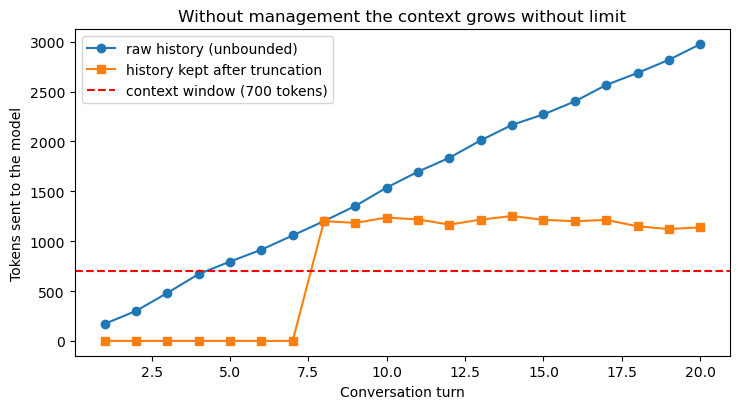

In [14]:
import random

random.seed(3)  # fixed values so the picture is reproducible

# Simulate a chat: every turn adds some tokens for the user and the assistant.
turn_sizes = []
for _ in range(20):
    user_t = random.randint(30, 80)      # user message
    asst_t = random.randint(50, 140)     # assistant reply
    turn_sizes.append(user_t + asst_t)

window = 700  # pretend the context window is 700 tokens

# Two strategies plotted together.
raw = []        # token count if we keep everything
managed = []    # token count if we trim to the last 8 turns
total = 0
for t, size in enumerate(turn_sizes):
    total += size
    raw.append(total)
    managed.append(sum(turn_sizes[t - 7:t + 1]))  # keep recent 8 turns

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(range(1, 21), raw, marker="o", label="raw history (unbounded)")
ax.plot(range(1, 21), managed, marker="s", label="history kept after truncation")
ax.axhline(window, color="red", linestyle="--",
           label=f"context window ({window} tokens)")
ax.set_xlabel("Conversation turn")
ax.set_ylabel("Tokens sent to the model")
ax.set_title("Without management the context grows without limit")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
class ChatSession:
    """A minimal conversational memory manager around our TeachingModel.

    It does two teaching jobs:
    1. Keeps the whole message list (the only 'memory' a chat has).
    2. Shows two ways to handle long chats: truncation and summarization.
    """

    def __init__(self, model: TeachingModel, system_prompt: str,
                 max_old_turns: int = 6) -> None:
        self.model = model
        self.system_prompt = system_prompt
        # The full memory of what we send to the model is 'self.history'.
        # system_prompt is kept separately in front of history.
        self.history: list[dict] = []
        self.max_old_turns = max_old_turns  # truncation window

    def send(self, text: str, temperature: float = 0.0) -> str:
        """Ask the model, then remember the exchange."""
        self.history.append({"role": "user", "content": text})
        messages = [{"role": "system", "content": self.system_prompt}] + self.history
        reply = self.model.chat(messages, temperature=temperature)
        self.history.append({"role": "assistant", "content": reply})
        return reply

    def truncate(self) -> None:
        """Strategy 1: forget the oldest turns beyond the window."""
        if len(self.history) > self.max_old_turns:
            remove = len(self.history) - self.max_old_turns
            self.history = self.history[remove:]
            print(f"[memory] truncated {remove} oldest message(s).")

    def summarize_old(self, keep_recent: int = 2) -> None:
        """Strategy 2: compress old turns into one synthetic 'assistant' message.

        Teachers often ask the model: 'summarize the conversation so far'.
        Here we simulate that with a fixed summary to keep the example offline.
        """
        if len(self.history) > keep_recent * 2:
            old = self.history[:-keep_recent * 2]
            recent = self.history[-keep_recent * 2:]
            point = " | ".join(f"{m['role']}:{m['content'][:30]}" for m in old)
            summary = {"role": "assistant",
                       "content": f"[Memory from earlier: {point}]"}
            self.history = [summary] + recent
            print(f"[memory] summarized {len(old)} old messages into one short memory.")

### Demonstration: a longer chat with memory management

Let's hold a conversation with several turns, then see how the session keeps
(or compresses) the memory.

In [16]:
model = TeachingModel(temperature=0.0)
session = ChatSession(
    model,
    system_prompt="You are a helpful assistant. Answer briefly.",
    max_old_turns=4,
)

# A short multi-turn conversation.
conversation = [
    "Hello! My name is Anna and I study biology.",
    "I am preparing a presentation about the cell.",
    "What is the main idea I should start with?",
    "Great, and which paragraph should come last?",
    "Tell me what 'temperature' means in programming.",
]

for turn in conversation:
    print("USER :", turn)
    print("ASST :", session.send(turn))
    print()

print("--- Memory management ---")
session.truncate()
print("Messages kept in memory after truncation:", len(session.history))
print("Model still knows your name? Let's ask:")
print("ASST :", session.send("What is my name?", temperature=0.0))

USER : Hello! My name is Anna and I study biology.
ASST : I am paying attention to your question about 'Hello! My name is Anna and I study biolo' Keep it short for you.

USER : I am preparing a presentation about the cell.
ASST : I am paying attention to your question about 'I am preparing a presentation about the' Keep it short for you.

USER : What is the main idea I should start with?
ASST : I am paying attention to your question about 'What is the main idea I should start wit' Keep it short for you.

USER : Great, and which paragraph should come last?
ASST : I am paying attention to your question about 'Great, and which paragraph should come l' Keep it short for you.

USER : Tell me what 'temperature' means in programming.
ASST : I am paying attention to your question about 'Tell me what 'temperature' means in prog' Keep it short for you.

--- Memory management ---
[memory] truncated 6 oldest message(s).
Messages kept in memory after truncation: 4
Model still knows your name? Let's

In [17]:
# Demonstrate summarization-based memory on a fresh session.
session2 = ChatSession(model, system_prompt="You are a helpful assistant.", max_old_turns=4)
for turn in ["I am Anna, a biologist.", "My topic is the cell membrane.",
             "Please explain it simply.", "Can you give me one example?",
             "And a second example as well?"]:
    session2.send(turn, temperature=0.0)

print(f"Messages before summarization: {len(session2.history)}")
session2.summarize_old(keep_recent=2)
print("Memory after summarization:")
for m in session2.history:
    print(f"  {m['role']}: {m['content'][:70]}")

Messages before summarization: 10
[memory] summarized 6 old messages into one short memory.
Memory after summarization:
  assistant: [Memory from earlier: user:I am Anna, a biologist. | assistant:I am pa
  user: Can you give me one example?
  assistant: I am paying attention to your question about 'Can you give me one exam
  user: And a second example as well?
  assistant: I am paying attention to your question about 'And a second example as 


In both demos we saw the essence of conversation: **the memory lives in the
program, not in the model.** With a real model the principle is identical - you
send the whole history with each request, and you manage the context window
yourself. (Notice in the truncation demo that after the oldest turns were
removed the assistant no longer knew the user's name: the "memory" really was
just that list.)

## 3.4 Connecting to a real model (optional)

Everything above used our small `TeachingModel`. Real assistants connect to a
**large language model over an API**:

1. The program sends an HTTP request containing the message list.
2. The cloud service runs the model and returns the generated reply.
3. The program adds the reply to its history and waits for the next turn.

Almost all providers today expose an **OpenAI-compatible API**, so the Python
package `openai` can talk to many different models (OpenAI, Yandex GPT,
Mistral, others) by simply changing `base_url` and your **API key**.

### Why credentials must be handled carefully

- Your **API key is like a password**: it authorizes *paid* requests.
- It must **never** be typed directly into the notebook (it would be saved with
  the file and could be seen by classmates).
- Best practice: keep it in an environment variable or a protected file that is
  **not shared**, and read it in your code.
- Never put secrets in files that are uploaded or committed.

The cell below respects these rules: it only reads credentials from a safe place,
and it does **nothing at all** unless you turn `RUN_LIVE` on. You can skip it
entirely and continue the course - no real model is required.

In [18]:
# --- OPTIONAL: connect to a real model ---------------------------------
# By default nothing is sent to any service. Set RUN_LIVE = True only if your
# teacher gave you credentials. This keeps the course free and private.

RUN_LIVE = False  # <-- leave False to keep every example offline

def make_live_model(base_url: str, model_name: str, api_key: str):
    """Return a function chat(messages, temperature) backed by a real model.

    It uses the `openai` package in 'OpenAI-compatible mode', which works with
    many providers (OpenAI, Yandex GPT, Mistral, ...).
    """
    from openai import OpenAI

    client = OpenAI(base_url=base_url, api_key=api_key)

    def chat(messages: list[dict], temperature: float = 0.7) -> str:
        response = client.chat.completions.create(
            model=model_name,
            messages=messages,
            temperature=temperature,
        )
        return response.choices[0].message.content

    return chat


if RUN_LIVE:
    import json
    import os

    # 1) Get the API key without hardcoding it. Look in an environment variable,
    #    or in the protected course file. Do NOT paste secrets in the notebook.
    key = os.getenv("API_KEY")
    if not key:
        cred_file = os.path.expanduser("/home/jovyan/__DATA/.accessyagpt")
        if os.path.exists(cred_file):
            with open(cred_file) as fh:
                key = json.load(fh).get("api_key")

    if not key:
        print("No API key found. Staying offline - that is fine.")
    else:
        # 2) Adjust these two lines to your provider: base_url and model id must
        #    match. For example OpenAI uses 'gpt-4o-mini', while Yandex GPT uses
        #    a model id such as 'yandexgpt-lite'.
        base_url = "https://llm.api.cloud.yandex.net/v1"     # adjust to your provider
        model_name = "gpt-4o-mini"                           # adjust to your model
        model_chat = make_live_model(base_url, model_name, key)
        print("Live model ready. Example:")
        print(model_chat(
            [{"role": "system", "content": "Answer briefly."},
             {"role": "user", "content": "Say hello in one short sentence."}],
            temperature=0.7,
        ))
else:
    print("Offline mode: no real model used. (Set RUN_LIVE = True only when you have credentials.)")

Offline mode: no real model used. (Set RUN_LIVE = True only when you have credentials.)


## 3.5 Part 3 - key takeaways

- A language model is **stateless**: it forgets everything between requests.
- Conversation **memory = the message list** that our program sends each time.
- The **context window** limits that list; manage it with **truncation** or **summarization**.
- Real assistants connect to a model through an **API** (usually OpenAI-compatible).
- **API keys are secrets**: keep them in protected files, never in notebooks.

**Self-check (think, then continue):**
1. In your own words: why does a chat assistant forget your name if the user closes the tab?
2. A model's context window is 8000 tokens. Your chat history needs 12000. Name the two strategies.
3. Why should you never paste an API key directly in a notebook?

---
In **Part 4** we look beyond plain chat: structured answers, tools, retrieval
(RAG), agents, and the limits and ethics we must respect when using assistants.

---

# Part 4 · Beyond chat, limits and ethics

**Approximate time: 1 academic hour.**

## 4.1 Learning outcomes

After this part you will be able to:

- Ask an assistant for **structured output** (JSON) and use it programmatically.
- Explain **RAG** (retrieval-augmented generation) and why it reduces mistakes.
- Describe **tools / function calling** and the **agent loop**.
- Recognize a real agent in action: the **OpenCode** assistant you are using.
- Use AI to **find, summarize and explain academic sources** safely.
- Name the main **limitations** of AI assistants (hallucinations, bias, privacy).
- Follow simple **responsible-use** rules when working with assistants.

## 4.2 Structured output: assistants that "return data"

So far our assistant replied with free text. Real applications often need a
**structured** answer, such as JSON, so a program can use the result. Because an
LLM follows instructions, you can ask it to *always reply in JSON*. Then your
program parses that JSON.

Example: extract structured information (sentiment + summary) from a review.
Our mock will "simulate" the model returning a JSON string, and then we parse
it - the same pattern a real app uses.

In [19]:
import json

# Simulate a model that is asked: "Return JSON with fields sentiment and summary".
def extract_review_info(review_text: str) -> dict:
    """Mimic a model call that returns structured data about a review.

    In a real system you would send a prompt like:
      'Classify the sentiment and summarize. Reply in JSON with keys
       "sentiment" and "summary" and nothing else.'
    """
    low = review_text.lower()
    sentiment = "positive" if any(w in low for w in ["great", "love", "excellent", "best"]) else \
                ("negative" if any(w in low for w in ["terrible", "bad", "hate", "worst"]) else "neutral")
    # Pretend the model produced this JSON text:
    json_text = json.dumps({"sentiment": sentiment,
                            "summary": review_text.strip()[:40] + "..."})
    return json.loads(json_text)  # <- the program parses the model's JSON


reviews = [
    "The course was excellent, I loved every lecture!",
    "The worst experience, terrible interface and bad support.",
    "It was okay, sometimes unclear.",
]
for review in reviews:
    info = extract_review_info(review)
    print(info["sentiment"].ljust(8), "|", info["summary"])

positive | The course was excellent, I loved every ...
negative | The worst experience, terrible interface...
neutral  | It was okay, sometimes unclear....


### Structured output enables instant analysis

Because the assistant returns *data* (not just prose), a program can do useful
things immediately: count, group, average, plot. Below we turn a batch of
reviews into a simple sentiment **bar chart** with just a few lines of code.
With a real model the extraction step would be identical - only the model call
changes.

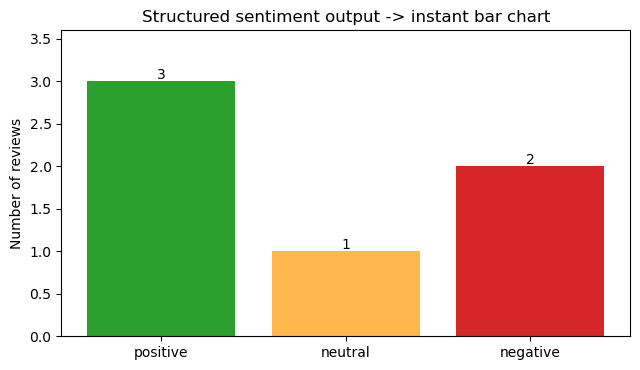

Sentiment summary: {'positive': 3, 'negative': 2, 'neutral': 1}


In [20]:
from collections import Counter

# A bigger batch of (made-up) reviews, processed by extract_review_info().
reviews = [
    "The course was excellent, I loved every lecture!",
    "The worst experience, terrible interface and bad support.",
    "Great material, best class I have attended.",
    "It was okay, sometimes unclear.",
    "I hate the assignment deadlines, the pace is bad.",
    "Love the examples - the teaching is excellent!",
]

sentiments = [extract_review_info(r)["sentiment"] for r in reviews]
counts = Counter(sentiments)

order = ["positive", "neutral", "negative"]
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.bar(order, [counts.get(x, 0) for x in order],
       color=["#2ca02c", "#ffb74d", "#d62728"])
ax.set_ylabel("Number of reviews")
ax.set_title("Structured sentiment output -> instant bar chart")
for i, o in enumerate(order):
    ax.text(i, counts.get(o, 0) + 0.03, str(counts.get(o, 0)), ha="center")
ax.set_ylim(0, max(counts.values()) * 1.2)
plt.tight_layout()
plt.show()

print("Sentiment summary:", dict(counts))

Structured output is what makes assistants useful **inside products**: an
e-commerce site can ship every review into a database as `{sentiment, summary}`,
a support system can route tickets to the right team, and so on.

## 4.3 RAG: helping the assistant with your own documents

A big problem with language models: they do **not** know your private documents,
your company data, or the latest news (their training had a cutoff date). RAG
fixes this by giving the model the *right documents* at answer time.

**Retrieval-Augmented Generation (RAG)** has three steps:

1. **Retrieve** - search a database for documents related to the question.
2. **Augment** - put those documents into the prompt ("context").
3. **Generate** - the model answers from that context.

Analogy: instead of making a student take an exam from memory, we give them the
relevant pages of the textbook and ask them to answer using those pages. Results
are more accurate and we are not forced to store all knowledge inside the model.

Let's build a tiny local RAG: a small private "company knowledge base" and a
search function, then feed matching documents into our mock model.

In [21]:
# Step 0: a tiny private knowledge base (e.g. company documents).
knowledge = {
    "holidays": "Company holidays: January 1-8 (New Year) and May 1-3 (Labour Day).",
    "salary":   "Salaries are paid on the 25th of each month by bank transfer.",
    "remote":   "Remote work is allowed on Fridays after submitting an approval form.",
}

# Step 1 + 2: RETRIEVE the relevant doc and AUGMENT the prompt with it.
def retriever(question: str) -> str:
    """Very simple keyword search over the knowledge base."""
    q = question.lower()
    for key, text in knowledge.items():
        if key in q:
            return text
    return "No private document matched this question."

# Step 3: GENERATE - send context + question to the model.
def rag_answer(question: str) -> str:
    context = retriever(question)
    docs = f"[Private knowledge] {context}"
    prompt = f"Answer using ONLY the private knowledge. Question: {question}"
    messages = [
        {"role": "system", "content": "You answer strictly from the provided context."},
        {"role": "user", "content": f"{docs}\n\n{prompt}"},
    ]
    # We print the exact messages the model sees; a real model would generate text.
    return messages


for question in ["When are the holidays?", "When is my salary paid?", "Can I work from home?"]:
    print("QUESTION:", question)
    for m in rag_answer(question):
        print(f"  {m['role']}: {m['content'][:90]}")
    print()

QUESTION: When are the holidays?
  system: You answer strictly from the provided context.
  user: [Private knowledge] Company holidays: January 1-8 (New Year) and May 1-3 (Labour Day).

An

QUESTION: When is my salary paid?
  system: You answer strictly from the provided context.
  user: [Private knowledge] Salaries are paid on the 25th of each month by bank transfer.

Answer 

QUESTION: Can I work from home?
  system: You answer strictly from the provided context.
  user: [Private knowledge] No private document matched this question.

Answer using ONLY the priv



Notice the pattern: we **control what the model knows** by choosing the context
we feed it. RAG makes assistants accurate on private data, and it is one of the
most common ways companies build custom assistants today.

## 4.4 Tools and agents: assistants that can "do things"

RAG gives assistants *facts*. **Tools** let them *act*:

- a **weather tool** to fetch live weather,
- a **calculator** to compute exactly,
- a **calendar** to schedule meetings,
- a **database search** to look up orders.

Modern assistants can **decide** which tool to call. When a program lets the
assistant run several steps and use several tools by itself to reach a goal,
we call it an **agent** (or *agentic assistant*). Example: "Book a dentist
appointment on Friday afternoon" → the agent searches your calendar, finds a
free slot, and writes an email confirmation.

The assistant usually replies in a special format saying *which tool to call
and with what arguments*; the program performs the call and gives the result
back to the model. (This is called **function calling**.) We already used a
form of this idea in the RAG example: the program did the *retrieval*, then
handed the result to the model.

In the next cell we connect the dots: you have been using such an agent all
along in this course - **OpenCode**.

## 4.5 You are already using an agent: OpenCode

The program you are using right now to read and work through this notebook -
**OpenCode** - is a real, everyday example of everything we just discussed. It
is an *agentic command-line assistant* that works with the same building blocks:

- a **conversation** between `user` and `assistant` messages (your requests and
  my replies are stored in a chat file, exactly like the message lists from Part 3);
- a **system prompt** that describes its persona and rules;
- a **language model** reached through an API (like our optional live cell);
- a set of **tools** - reading files, searching for text, running shell
  commands, editing and creating files;
- and an **agent loop** that repeats: *decide which tool to call → run it →
  read the result → move to the next step → repeat until the task is done*.

So when you asked me to build this course, I did the same loop many times:
read the notebook, run the code, find an error, edit a cell, re-run, and so on.
The model is *the brain that decides*; the tools are *the hands that act*; the
loop is *the workflow that connects them*.

The diagram and the small example below show this loop in action.

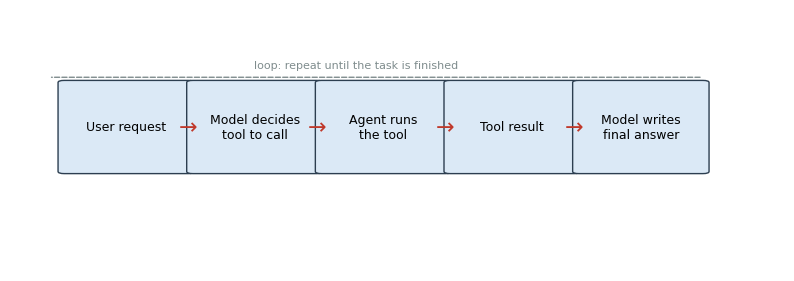

In [22]:
# The agent loop, drawn. Each box is a step an agent repeats.
import matplotlib.patches as mpatch

steps = ["User request", "Model decides\ntool to call", "Agent runs\nthe tool",
         "Tool result", "Model writes\nfinal answer"]
n = len(steps)
w, gap = 0.16, 0.006
x0, y0, h = 0.07, 0.38, 0.34

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.axis("off")
for i, s in enumerate(steps):
    x = x0 + i * (w + gap)
    ax.add_patch(mpatch.FancyBboxPatch(
        (x, y0), w, h, boxstyle="round,pad=0.008", fc="#dbe9f6", ec="#2c3e50"))
    ax.text(x + w / 2, y0 + h / 2, s, ha="center", va="center", fontsize=9)
# forward arrows
for i in range(n - 1):
    ax.text(x0 + i * (w + gap) + w, y0 + h / 2, "→",
            ha="center", va="center", fontsize=16, color="#c0392b")
# return loop arrow (the loop repeats until done)
ax.annotate("", xy=(x0 - 0.02, y0 + h + 0.02), xytext=(x0 + (n - 1) * (w + gap) + w, y0 + h + 0.02),
            arrowprops=dict(arrowstyle="-", color="#7f8c8d", linestyle="--"))
ax.text((x0 + (n - 1) * (w + gap) + w) / 2, y0 + h + 0.055,
        "loop: repeat until the task is finished", ha="center",
        fontsize=8, color="#7f8c8d")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.show()

### A mini agent with tool calling (hands-on)

Real agents send the model a list of available tools and let it reply with the
name and arguments of the tool it wants to use. To keep this example offline,
we *simulate that decision* with simple keyword rules - but the shape is the
same as in OpenCode: a request, a chosen tool, and a result that is turned into
an answer.

In [23]:
# A mini agent: the "model" picks a tool, the agent runs it, result -> answer.
# The structure mirrors how OpenCode (and other agents) do function calling.

facts = {"course": "01 Introduction to AI Assistants", "hours": 4}

TOOLS = {
    "calculate": {
        "description": "Add two numbers together.",
        "run": lambda args: args["a"] + args["b"],
    },
    "lookup": {
        "description": "Look up a fact in the small knowledge base.",
        "run": lambda args: facts.get(args["key"], "not found"),
    },
    "count_tokens": {
        "description": "Roughly count the tokens of a text.",
        "run": lambda args: estimate_tokens(args["text"]),
    },
}

def decide(request: str) -> tuple[str, dict]:
    """Simulate the model choosing a tool and arguments from the request.

    Specific keywords are checked first, then more general ones. This mirrors
    how a real model would pick the right tool for a request.
    """
    r = request.lower()
    if "token" in r:
        return "count_tokens", {"text": "OpenCode is an agentic assistant."}
    if "course" in r:
        return "lookup", {"key": "course"}
    if "add" in r or "sum" in r or "+" in r:
        return "calculate", {"a": 3, "b": 4}
    return "explain", {}

def agent_round(request: str) -> None:
    """One loop iteration: decide -> run tool -> turn the result into an answer."""
    tool, args = decide(request)
    print("USER      :", request)
    if tool == "explain":
        print("ASSISTANT : That request is outside my tools, so I answer in plain text.")
        print()
        return
    result = TOOLS[tool]["run"](args)
    print(f"TOOL CALL : {tool} with arguments {args}")
    print(f"TOOL RESULT: {result}")
    print("ASSISTANT : Using that result, I can answer you now.")
    print()


agent_round("Please add 3 and 4.")
agent_round("What is the name of this course?")
agent_round("About how many tokens is that small sentence?")
agent_round("Tell me a story about robots.")

USER      : Please add 3 and 4.
TOOL CALL : calculate with arguments {'a': 3, 'b': 4}
TOOL RESULT: 7
ASSISTANT : Using that result, I can answer you now.

USER      : What is the name of this course?
TOOL CALL : lookup with arguments {'key': 'course'}
TOOL RESULT: Introduction to AI Assistants
ASSISTANT : Using that result, I can answer you now.

USER      : About how many tokens is that small sentence?
TOOL CALL : count_tokens with arguments {'text': 'OpenCode is an agentic assistant.'}
TOOL RESULT: 9
ASSISTANT : Using that result, I can answer you now.

USER      : Tell me a story about robots.
ASSISTANT : That request is outside my tools, so I answer in plain text.



## 4.6 Limitations you must always remember

AI assistants are powerful but **not infallible**:

- **Hallucinations.** They can invent confident-sounding but false facts.
  Always verify important information (this is why RAG feeds them facts).
- **Outdated knowledge.** Their training has a cutoff date; they do not know
  the latest news by themselves.
- **Bias.** They learned from human text, which contains prejudices. Outputs can
  reflect stereotypes - review sensitive answers.
- **Privacy.** Conversations are often sent to remote servers. Never input
  passwords, personal data, or secrets you are not allowed to share.
- **Tool mistakes.** An agent that *can* run tools must also *check* their
  results - a tool can be misused (running a wrong command, editing the wrong
  file), so a human should review important actions.
- **No guarantees.** A model does not have true understanding or intent; it
  predicts text. Treat it as a very good assistant, not as a source of truth.

These limitations apply to OpenCode too: always review what it changed before
trusting it - the same rule as with any agent.

## Quick reference: which technique when?

A handy summary of everything we have covered, for day-to-day use:

| I need to... | Best approach | Where it lives |
|--------------|---------------|----------------|
| Get a clear factual explanation | Clear instructions + low temperature (+ persona if the level matters) | Part 2 |
| Force a specific format (JSON, list, table) | Output control + few-shot examples | Part 2 |
| Reason step by step about math / logic | Chain-of-thought prompting | Part 2 |
| Brainstorm creative ideas | High temperature | Part 2 |
| Answer from my own documents / private data | RAG (retrieve + feed context) | Part 4 |
| Let the assistant actually do something | Tools / function calling (agents) | Part 4 |
| Have an agent build or fix a project for me | An agentic ASSISTANT such as OpenCode | Part 4 (4.5) |
| Use AI responsibly for homework / research | The workflow in 4.7 + the rules in 4.8 | Part 4 |

## 4.7 Using AI to find, summarize and explain academic sources

AI assistants are powerful helpers for academic work - as long as we treat them
as a **tool**, not as a source of truth. Here is a safe three-step workflow.

### Step 1 - FIND sources

- A model usually **cannot browse the web by itself** (unless it has a search
  tool or RAG, see Sections 4.3-4.4). Ask it to generate **keywords, synonyms
  and search queries**, then type those into a real library database
  (Google Scholar, your university's catalog, etc.).
- For documents you provide yourself (course reader, uploaded PDF), the model
  retrieves from that material - exactly the RAG idea we built above.
- **Never** ask the model to invent references. It often fabricates convincing
  but fake citations (a form of hallucination). Always keep a real source you
  can open.

### Step 2 - SUMMARIZE

- Paste the abstract or a paragraph and request a structured summary, for
  example: *"summarize this in 3 bullets: research question, method, main result."*
- Paraphrase the summary **in your own words** and always cite the paper.
- If something is unclear, ask the assistant to re-explain it more simply.

### Step 3 - EXPLAIN

- Combine **persona + output control** (Part 2): *"explain this result to a
  first-year student"* or *"explain it as if I could ask the authors one question."*
- Treat clarifications as a starting point, then **verify by reading the paper**.

### Golden rules

1. Verify everything: check quotes, numbers and pages against the real source.
2. Cite the papers, never the assistant; the AI does not decide citation rules.
3. Keep private data and drafts out of assistants you do not trust fully.
4. Be transparent: disclose AI help when your course asks you to.

The next cell runs this workflow (FIND -> SUMMARIZE -> EXPLAIN) offline with our mock.

In [24]:
# Academic workflow demo (offline, with our TeachingModel).

# STEP 1 - FIND: simulate a search/retrieval over a small "reading list".
reading_list = {
    "transformer": "Vaswani et al. (2017), 'Attention is all you need'",
    "few-shot":    "Brown et al. (2020), 'Language Models are Few-Shot Learners'",
}

def find_source(query: str) -> str:
    """Retrieve a matching reference, like a library search would."""
    for key, ref in reading_list.items():
        if key in query.lower():
            return ref
    return "No exact match - try keywords like 'transformer' or use a library database."


# STEP 2 - SUMMARIZE: show the model a real snippet and ask for a structured summary.
abstract = (
    "We propose a new network architecture, the Transformer, based solely on "
    "attention mechanisms and dispensing with recurrence altogether. Experiments "
    "on two machine translation tasks show that these models are superior in "
    "quality while being more parallelizable and requiring significantly less "
    "time to train."
)
model_ai = TeachingModel(temperature=0.1)
summary_prompt = ("Summarize this paragraph in 2 bullet points, then state the main "
                  "result in one short sentence.\n\n" + abstract)

print("FIND   :", find_source("Which paper introduced the transformer?"))
print("\nReal model's summary would look like:")
print("  - The paper proposes the Transformer, an architecture based only on attention.")
print("  - It avoids recurrence, so it is parallel and trains faster.")
print("  Main result: better translation quality in less training time.")
print("\nMOCK reply (our offline model):")
print("  ", ask(model_ai, summary_prompt,
                "You are a research assistant who answers briefly.", 0.1))


# STEP 3 - EXPLAIN: persona + output control for a specific audience.
print("\nEXPLAIN (to a first-year student):")
print("  ", ask(
    model_ai,
    "Explain in 2 simple sentences what the Transformer architecture is about.",
    "You are a friendly teacher for a first-year student. Answer briefly.",
    0.3,
))

FIND   : Vaswani et al. (2017), 'Attention is all you need'

Real model's summary would look like:
  - The paper proposes the Transformer, an architecture based only on attention.
  - It avoids recurrence, so it is parallel and trains faster.
  Main result: better translation quality in less training time.

MOCK reply (our offline model):
   A summary should keep only the key points and a short title Keep it short for you.

EXPLAIN (to a first-year student):
   I am paying attention to your question about 'Explain in 2 simple sentences what the T' Does this make sense so far?


## 4.8 Responsible use: a short checklist

1. **Don't share secrets.** Keep personal and financial data out of assistants unless the tool is private.
2. **Verify before acting.** Check numbers, quotes, and instructions before relying on them (especially in medicine, finance, law).
3. **Review agent changes.** When an agent edits files or runs commands, read the result before trusting it (this applies to OpenCode too).
4. **Be transparent.** If an assistant helped write something, say so - honesty matters.
5. **Understand the limit of authority.** Assistants must not silently make decisions that need human judgment.
6. **Question bias.** Look critically at answers about people and minorities.

## 4.9 The full picture

You now have the whole map of an AI assistant:

```
user message
    │
    ▼
CONVERSATION  (message list with roles: system / user / assistant)
    │
    ▼
CONTEXT  (context window; managed by truncation or summarization)
    │
    ▼
ENHANCEMENT  (optional: RAG documents, tools, function calls)
    │
    ▼
MODEL  (tokenizes text, predicts generation, uses temperature)
    │
    ▼
reply  ─┬─ straight to the user
        ├─ as structured JSON for programs
        └─ as a TOOL CALL -> agent runs it -> result returns to the model (loop)
```

## 4.10 Take-home task (pick one)

1. **Prompt clinic.** Take any question you care about and write it with the
   CATA recipe from Part 2. Ask the same question with and without examples;
   write down which answer you prefer and why.
2. **Mini RAG.** Using the `knowledge` idea, build a 5-document "knowledge base"
   about a topic you study and a `retriever` + prompt.
3. **Academic assistant.** Take one abstract from a paper you read. Practice the
   FIND -> SUMMARIZE -> EXPLAIN workflow from Section 4.7: generate search
   keywords, ask for a structured summary, and have it explained to a beginner.
   Then open the paper and check the summary against the real text.
4. **Mini agent.** Add a new tool to the mini agent from Section 4.5 (for
   example "multiply" or "reverse this text"), give it a description, and make
   `decide()` route a new request to it. Print one full loop iteration.
5. **Review an assistant.** Chat with any agentic assistant (for example
   OpenCode). Find one answer that may be a hallucination or biased, and explain
   which checklist item (4.8) it touches.

## 4.11 Final self-check (whole course)

1. Name the difference between a rule-based chatbot and a model-based assistant.
2. What are the three message roles and which one shapes behavior?
3. What does temperature control? When would you lower it?
4. Why is "the model has memory" a misconception? How is memory implemented?
5. What are the two ways to handle a too-long context window?
6. Give a one-sentence definition of RAG and of an agent.
7. List three limitations of AI assistants (now that we added agents, you can name ones specific to tools).
8. Why should you never let an AI assistant write your reference list for you?
9. In what order does the agent loop run when you ask OpenCode to "fix an error"?

You can discuss your answers with a classmate or your teacher. Look up any term
you are unsure about in `glossary.md`.

## 4.12 References and further reading

If you want to go deeper (all optional at this level):

- **Prompt engineering guides** (free public docs) by OpenAI, Anthropic and Google.
- **OpenAI API documentation** - how `chat.completions` messages and tool/function calling work.
- **"Attention is all you need"** (Vaswani et al., 2017) - the paper that introduced the Transformer.
- **OpenCode (opencode.ai)** - the open-source agentic assistant you are using in this course.
- **Your library's research guides** - how to search databases and cite properly.
- **glossary.md** in this catalog - every term used in the course, in one place.

---

Thank you for completing *Introduction to AI Assistants*. You now understand
what an assistant is, how to talk to it (prompts, temperature, few-shot,
persona, chain-of-thought), how conversation memory works, how advanced
techniques (RAG, tools, agents - including OpenCode) extend it, how to use
assistants for academic work, and the limits and ethics that come with it.